In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("Netfix_data.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(5398, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5398 entries, 0 to 5397
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5398 non-null   object 
 1   type          5398 non-null   object 
 2   title         5397 non-null   object 
 3   director      3515 non-null   object 
 4   cast          4903 non-null   object 
 5   country       4735 non-null   object 
 6   date_added    5397 non-null   object 
 7   release_year  5397 non-null   float64
 8   rating        5397 non-null   object 
 9   duration      5397 non-null   object 
 10  listed_in     5397 non-null   object 
 11  description   5397 non-null   object 
dtypes: float64(1), object(11)
memory usage: 506.2+ KB


In [ ]:
df.describe()

,release_year
count,5397.000000
mean,2016.083936
std,7.121457
min,1925.000000
25%,2016.000000
50%,2018.000000
75%,2020.000000
max,2021.000000


data cleaning

In [ ]:
print(df.isnull().any())

show_id         False
type            False
title            True
director         True
cast             True
country          True
date_added       True
release_year     True
rating           True
duration         True
listed_in        True
description      True
dtype: bool


In [ ]:
print(df.isnull().sum().sum())

3048


In [ ]:
print(df.isnull().mean()*100)

show_id          0.000000
type             0.000000
title            0.018525
director        34.883290
cast             9.170063
country         12.282327
date_added       0.018525
release_year     0.018525
rating           0.018525
duration         0.018525
listed_in        0.018525
description      0.018525
dtype: float64


In [ ]:
df["director"].fillna("No director",inplace= True)
df["cast"].fillna("No cast",inplace=True)
df["country"].fillna("No country",inplace= True)
df.dropna(subset=["date_added","rating"],inplace=True)

/tmp/ipython-input-1169620887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("No director",inplace= True)
/tmp/ipython-input-1169620887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


# **1. How has the number of movies released per year changed over the last 20-30 years?**

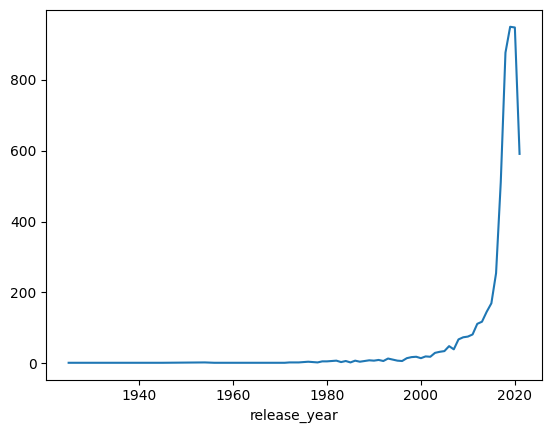

In [ ]:
df.groupby("release_year")["title"].count().plot(kind="line")
plt.show()

In [ ]:
m=df.loc[df["type"]=="Movie"]

In [ ]:
m.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",No country,"September 24, 2021",2021.0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993.0,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021.0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021.0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [ ]:
yr_wise_movie=m["release_year"].value_counts()
print(yr_wise_movie)

release_year
2019.0    562
2018.0    558
2020.0    514
2017.0    352
2021.0    277
2016.0    177
2015.0    116
2014.0    112
2013.0     96
2012.0     91
2011.0     66
2010.0     62
2009.0     59
2008.0     56
2006.0     39
2007.0     31
2004.0     27
2005.0     26
2003.0     23
2001.0     18
1998.0     16
1999.0     16
1997.0     13
2002.0     12
2000.0     11
1993.0     10
1994.0      9
1991.0      9
1989.0      8
1990.0      7
1982.0      7
1986.0      6
1996.0      6
1984.0      6
1995.0      6
1981.0      6
1992.0      5
1979.0      5
1988.0      5
1980.0      5
1976.0      4
1987.0      4
1975.0      3
1983.0      3
1978.0      2
1985.0      2
1973.0      2
1954.0      2
1961.0      1
1972.0      1
1964.0      1
1959.0      1
1958.0      1
1956.0      1
1963.0      1
1970.0      1
1960.0      1
1974.0      1
1966.0      1
1971.0      1
Name: count, dtype: int64


In [ ]:
yr_wise_movie.sort_values(ascending=False).head(30)

,count
release_year,
2019.0,562
2018.0,558
2020.0,514
2017.0,352
2021.0,277
2016.0,177
2015.0,116
2014.0,112
2013.0,96


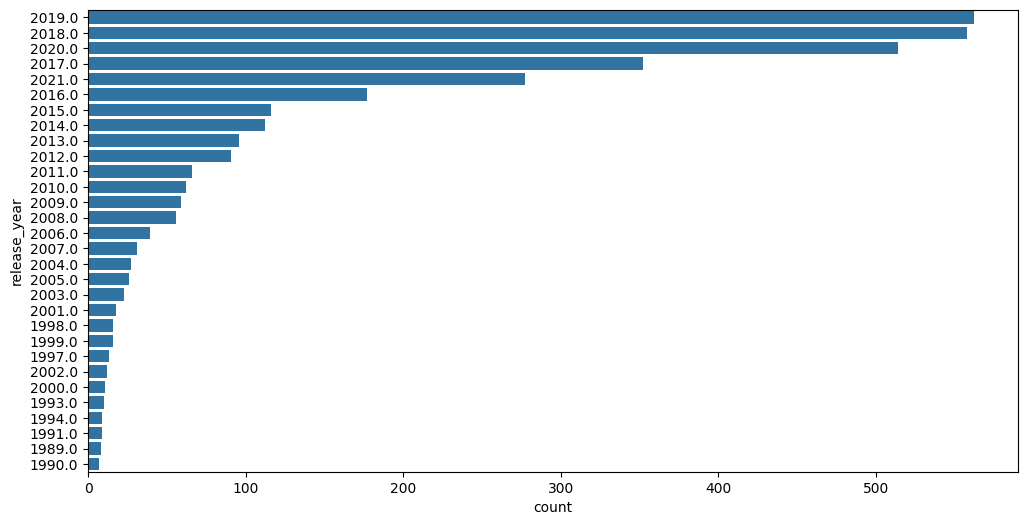

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="release_year",
    data=m,
    order=m["release_year"].value_counts().index[:30]
)
plt.show()

***insights for movies released per year over last 20-30 years***


 1. Slow growth in early years (1990–2005)
Very few movies were added each year.
 2. Steady rise after 2010, the number of movies starts increasing clearly.
 3. Massive jump after 2015, the growth becomes very sharp.

    *This is when: Netflix started producing original movies*

 4. Peak years around 2017–2020. These years show the highest number of movie releases.

    *Indicates:
    Aggressive expansion strategy*

# **2. Comparison of tv shows vs. movies.**


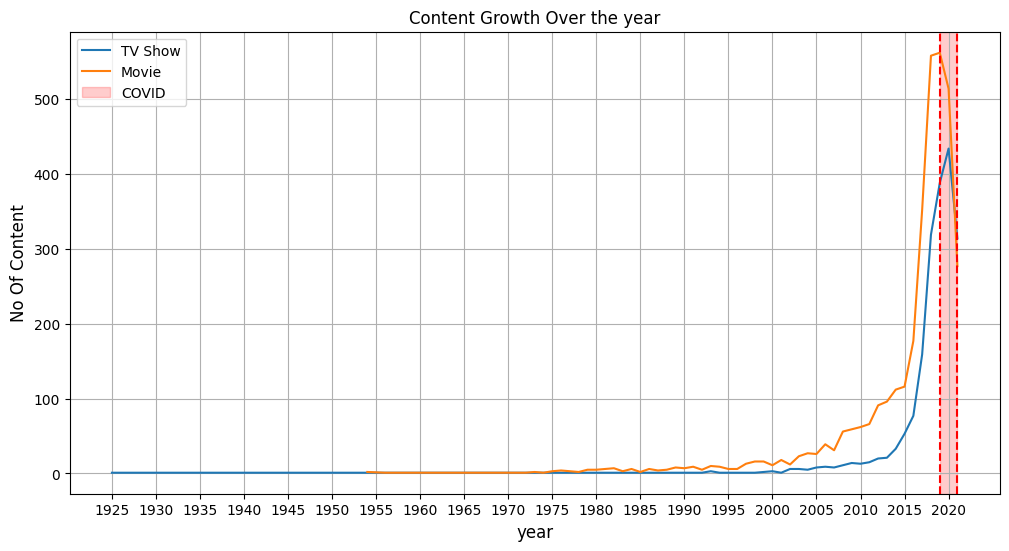

In [ ]:
TV=df.loc[df['type']=='TV Show']
Movie=df.loc[df['type']=='Movie']

TV_showProgress=TV['release_year'].value_counts().sort_index()
MovieProgress=Movie['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(TV_showProgress.index,TV_showProgress.values,label="TV Show")
plt.plot(MovieProgress.index,MovieProgress.values,label="Movie")
plt.axvline(2019,linestyle="--",color="r")
plt.axvline(2021,linestyle="--",color="r")
plt.axvspan(2019,2021,alpha=0.2,color="r",label="COVID")
plt.title("Content Growth Over the year")
plt.xlabel("year",fontsize=12)
plt.ylabel('No Of Content',fontsize=12)
plt.legend()
plt.xticks(range(1925,2025,5),fontsize=10)
plt.grid()

plt.show()

1.  Both movies and TV shows increase slowly at first.

    After 2015, growth becomes very sharp — especially for movies.

2. The highlighted COVID window from (2019-2021) shows:

    Disruption in production , But also higher streaming demand

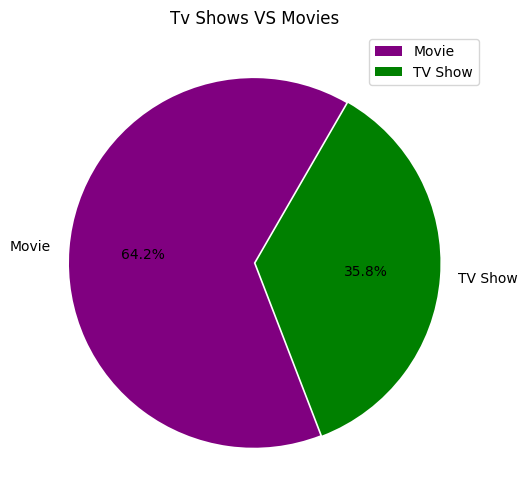

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Tv Shows VS Movies")
plt.pie(df['type'].value_counts(),explode=(0.005,0.005),labels=df['type'].value_counts().index,colors=['purple','green'],autopct='%.1f%%',startangle=60)
plt.legend()
plt.show()

**Finall insight**
1. Movies form the majority of Netflix’s content library, but TV shows contribute a significant share.
2. Movies - quick consumption, wide audience

    TV Shows - user retention, binge-watching
3. Netflix’s content production increased slowly in the early years but accelerated sharply after 2015.
4. More content = more subscriptions

    Content volume is a key competitive advantage

# **3. what is the best time to launch a tv show?**

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 0 to 5396
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       5397 non-null   object 
 1   type          5397 non-null   object 
 2   title         5397 non-null   object 
 3   director      5397 non-null   object 
 4   cast          5397 non-null   object 
 5   country       5397 non-null   object 
 6   date_added    5397 non-null   object 
 7   release_year  5397 non-null   float64
 8   rating        5397 non-null   object 
 9   duration      5397 non-null   object 
 10  listed_in     5397 non-null   object 
 11  description   5397 non-null   object 
dtypes: float64(1), object(11)
memory usage: 677.2+ KB


In [ ]:
df['date_added'].nunique()

1177

In [ ]:
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 0 to 5396
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5397 non-null   object        
 1   type          5397 non-null   object        
 2   title         5397 non-null   object        
 3   director      5397 non-null   object        
 4   cast          5397 non-null   object        
 5   country       5397 non-null   object        
 6   date_added    5397 non-null   datetime64[ns]
 7   release_year  5397 non-null   float64       
 8   rating        5397 non-null   object        
 9   duration      5397 non-null   object        
 10  listed_in     5397 non-null   object        
 11  description   5397 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 677.2+ KB


In [ ]:
df['Year']=df["date_added"].dt.year
df["month"]=df["date_added"].dt.month
df["date"]=df["date_added"].dt.day

In [ ]:
df1=df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 0 to 5396
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5397 non-null   object        
 1   type          5397 non-null   object        
 2   title         5397 non-null   object        
 3   director      5397 non-null   object        
 4   cast          5397 non-null   object        
 5   country       5397 non-null   object        
 6   date_added    5397 non-null   datetime64[ns]
 7   release_year  5397 non-null   float64       
 8   rating        5397 non-null   object        
 9   duration      5397 non-null   object        
 10  listed_in     5397 non-null   object        
 11  description   5397 non-null   object        
 12  Year          5397 non-null   int32         
 13  month         5397 non-null   int32         
 14  date          5397 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3),

In [ ]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year,month,date
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24


In [ ]:
df1["week"] = df1["date_added"].dt.isocalendar().week.astype("int32")

In [ ]:
TV=df1.loc[df1['type']=='TV Show']

In [ ]:
print(df1.groupby('Year')['title'].nunique().reset_index())

   Year  title
0  2017    297
1  2018    871
2  2019   1152
3  2020   1607
4  2021   1470


In [ ]:
print(df1.groupby('week')['title'].nunique().reset_index())

    week  title
0      1    115
1      2     61
2      3     71
3      4     63
4      5    103
5      6     69
6      7     87
7      8     63
8      9    121
9     10     74
10    11     93
11    12     78
12    13    120
13    14    111
14    15    103
15    16     99
16    17    109
17    18    146
18    19     83
19    20     88
20    21     87
21    22    112
22    23     95
23    24    128
24    25     88
25    26    167
26    27    169
27    28     85
28    29    104
29    30    114
30    31    134
31    32     98
32    33     91
33    34    105
34    35    169
35    36    101
36    37    124
37    38    101
38    39     73
39    40    190
40    41     69
41    42    103
42    43     85
43    44    173
44    45     70
45    46     98
46    47     76
47    48    130
48    49     90
49    50    108
50    51     96
51    52     65
52    53     42


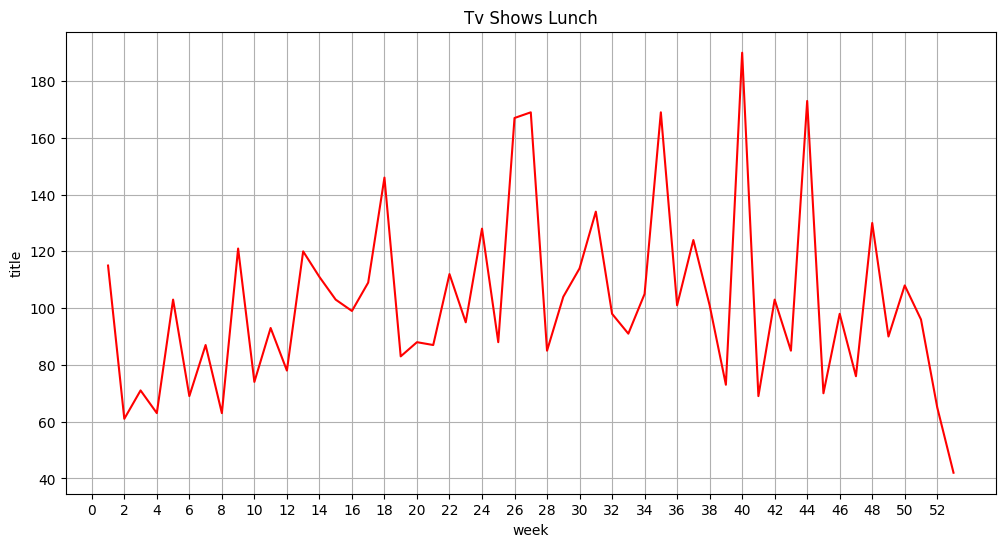

In [ ]:
df_week=df1.groupby('week')['title'].nunique().reset_index()
plt.figure(figsize=(12,6))
plt.title("Tv Shows Lunch")
sns.lineplot(data=df_week,x='week',y='title',color='red')
plt.xticks(range(0,54,2),fontsize=10)
plt.grid()
plt.show()

In [ ]:
print(df1.groupby('month')['title'].nunique().reset_index())

    month  title
0       1    338
1       2    325
2       3    402
3       4    479
4       5    420
5       6    473
6       7    548
7       8    490
8       9    528
9      10    482
10     11    455
11     12    457


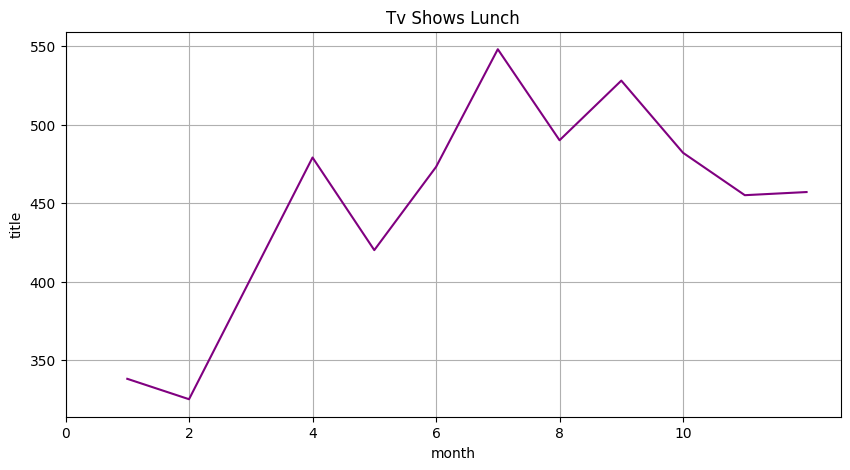

In [ ]:
df_month=df1.groupby('month')['title'].nunique().reset_index()
plt.figure(figsize=(10,5))
plt.title("Tv Shows Lunch")
sns.lineplot(data=df_month,x='month',y='title',color='purple')
plt.xticks(range(0,12,2),fontsize=10)
plt.grid()
plt.show()

**Insight on best time to launch a tv-show**
1. Highest launches happen around:

    July

    December
2. Lowest launches happen around:

    February

    May

3. Best launch months

    July → peak engagement, mid-year momentum

    December → holiday season, maximum free time

4. TV shows are not launched randomly. There is a clear seasonal pattern in release strategy.

5. Avoid launching in

    February → lowest activity

    May → audience busy with exams, travel, outdoor time

# **4.  Analysis of actors/directors of different types of shows/movies.**

In [ ]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year,month,date,week
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25,38
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,38
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24,38
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24,38
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24,38


In [ ]:
tv = df1.loc[df1["type"] == "TV Show"]

In [ ]:
tv_actors = tv["cast"].str.split(",").explode().value_counts().head(10)
print(tv_actors)

cast
No cast              258
 Takahiro Sakurai     20
 Junichi Suwabe       16
 Ai Kayano            15
 Yuki Kaji            14
 Daisuke Ono          13
 Kana Hanazawa        12
 Yoshimasa Hosoya     12
 Yuichi Nakamura      11
 Nobuhiko Okamoto     11
Name: count, dtype: int64


In [ ]:
movie = df1.loc[df1["type"] == "Movie"]

In [ ]:
movie_actors = movie["cast"].str.split(",").explode().value_counts().head(10)
print(tv_actors)

cast
No cast              258
 Takahiro Sakurai     20
 Junichi Suwabe       16
 Ai Kayano            15
 Yuki Kaji            14
 Daisuke Ono          13
 Kana Hanazawa        12
 Yoshimasa Hosoya     12
 Yuichi Nakamura      11
 Nobuhiko Okamoto     11
Name: count, dtype: int64


In [ ]:
tv_actors.equals(movie_actors)

False

In [ ]:
tv_directors = tv["director"].str.split(",").explode().value_counts().head(10)
print(tv_directors)

director
No director                1754
Joe Berlinger                 2
Hsu Fu-chun                   2
 Gautham Vasudev Menon        2
Rob Seidenglanz               2
Shin Won-ho                   2
Mike Flanagan                 1
Julien Leclercq               1
Luis Alfaro                   1
 Javier Gómez Santander       1
Name: count, dtype: int64


In [ ]:
movie_directors = movie["director"].str.split(", ").explode().value_counts().head(10)
print(movie_directors)

director
No director            128
Rajiv Chilaka           19
Suhas Kadav             15
Jan Suter               15
Raúl Campos             14
Cathy Garcia-Molina     12
Youssef Chahine         12
Marcus Raboy            12
Jay Chapman              9
Don Michael Paul         8
Name: count, dtype: int64


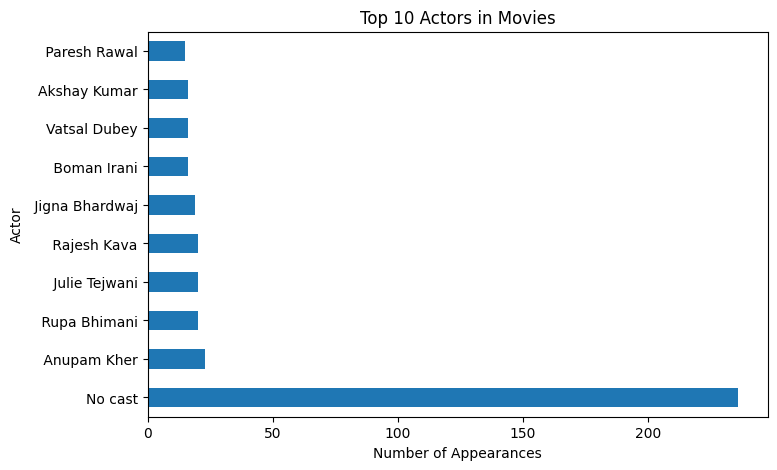

In [ ]:
movie_actors.plot(kind="barh",figsize=(8,5))
plt.title("Top 10 Actors in Movies")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.show()

**Top Actors in Movies**
1. A large number of movies don’t list cast properly (“No cast” is very high), showing a data quality gap.
2. Among named actors, a few actors appear repeatedly like (anupam kher, om puri, shah rukh khan)  showing strong collaboration patterns.
3. Movie casting seems diverse, with no single actor completely dominating.

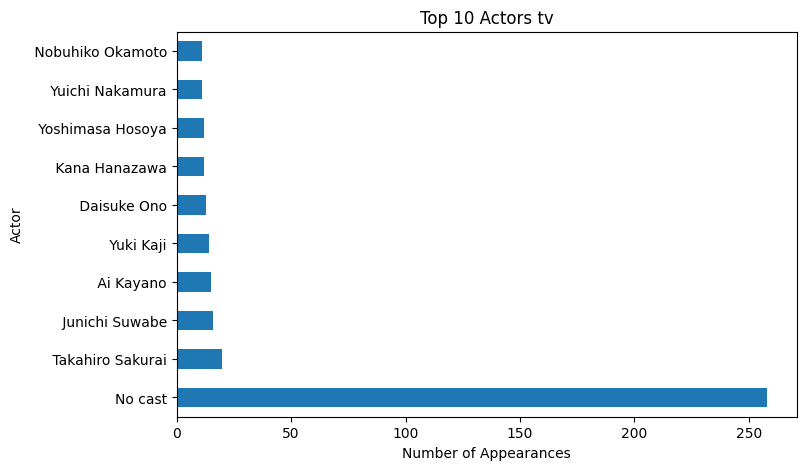

In [ ]:
tv_actors.plot(kind="barh",figsize=(8,5))
plt.title("Top 10 Actors tv")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.show()

**Top Actors in TV Shows**
1. its shows same as any other graph that , showing a data quality gap for no cast.
2. TV shows show more repeat actors compared to movies, indicating long-term casting strategies.
3. This helps build viewer familiarity and loyalty to certain faces.

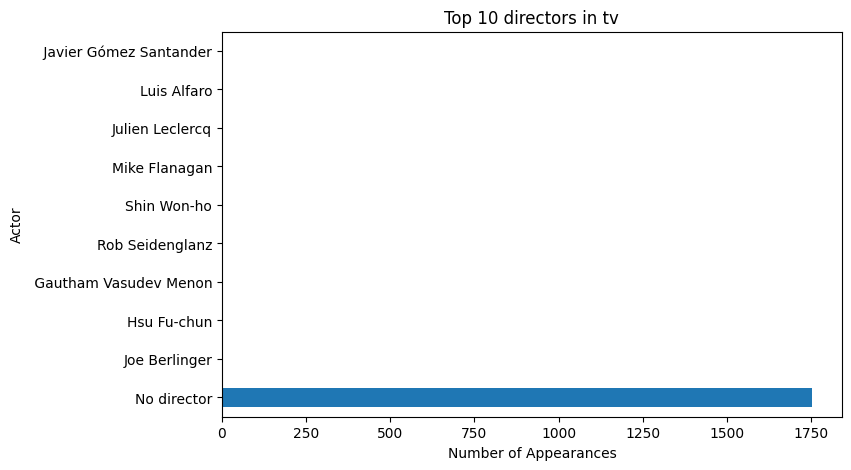

In [ ]:
tv_directors.plot(kind="barh",figsize=(8,5))
plt.title("Top 10 directors in tv")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.show()

**Top Directors in TV Shows**
1. The biggest bar is “No director”, which means
most TV shows don’t have director information filled in the dataset.
2. Among named directors, no single person dominates,
All listed directors have very similar and low counts.
3. This shows Netflix does not depend on just one or two directors for TV shows.
4. Unlike movies, TV series usually have:

    multiple episode directors

    showrunners instead of one lead director

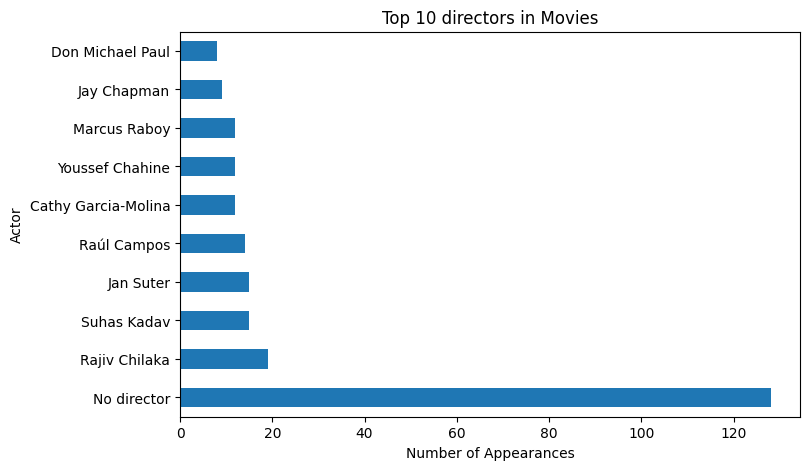

In [ ]:
movie_directors.plot(kind="barh",figsize=(8,5))
plt.title("Top 10 directors in Movies")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.show()

**Top Directors in Movies**
1. A very large number of movies fall under “No director”, again showing missing metadata.
2. Among known directors, there is high diversity, meaning Netflix works with many creators.
3. This shows Netflix does not rely on just one or two star directors for movies.
4. still  there are some known directors which netflix works most with like(rajiv chilaka, jan suter, raul, campos and etc).

# **5. Does Netflix has more focus on TV Shows than movies in recent years**


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5397 entries, 0 to 5396
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       5397 non-null   object        
 1   type          5397 non-null   object        
 2   title         5397 non-null   object        
 3   director      5397 non-null   object        
 4   cast          5397 non-null   object        
 5   country       5397 non-null   object        
 6   date_added    5397 non-null   datetime64[ns]
 7   release_year  5397 non-null   float64       
 8   rating        5397 non-null   object        
 9   duration      5397 non-null   object        
 10  listed_in     5397 non-null   object        
 11  description   5397 non-null   object        
 12  Year          5397 non-null   int32         
 13  month         5397 non-null   int32         
 14  date          5397 non-null   int32         
 15  week          5397 non-null   int32        

In [ ]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year,month,date,week
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25,38
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,38
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24,38
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24,38
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24,38


In [ ]:
year_type_counts = (df1.groupby(["Year", "type"])["title"].count().unstack(fill_value=0).sort_index())

In [ ]:
year_type_counts.tail(10).reset_index()

type,Year,Movie,TV Show
0,2017,182,115
1,2018,601,270
2,2019,682,470
3,2020,1033,574
4,2021,966,504


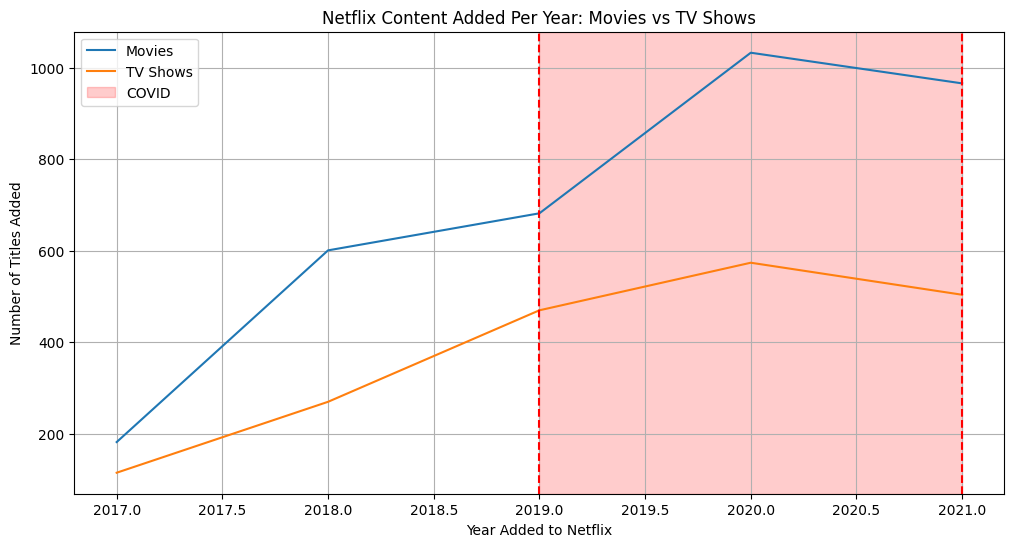

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(year_type_counts.index, year_type_counts.get("Movie", 0), label="Movies")
plt.plot(year_type_counts.index, year_type_counts.get("TV Show", 0), label="TV Shows")
plt.axvline(2019,linestyle="--",color="r")
plt.axvline(2021,linestyle="--",color="r")
plt.axvspan(2019,2021,alpha=0.2,color="r",label="COVID")
plt.title("Netflix Content Added Per Year: Movies vs TV Shows")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles Added")
plt.grid()
plt.legend()
plt.show()

In [ ]:
share1 = year_type_counts.div(year_type_counts.sum())*100
share = share1.round(2)
print(share)

type  Movie  TV Show
Year                
2017   5.25     5.95
2018  17.35    13.97
2019  19.69    24.31
2020  29.82    29.69
2021  27.89    26.07


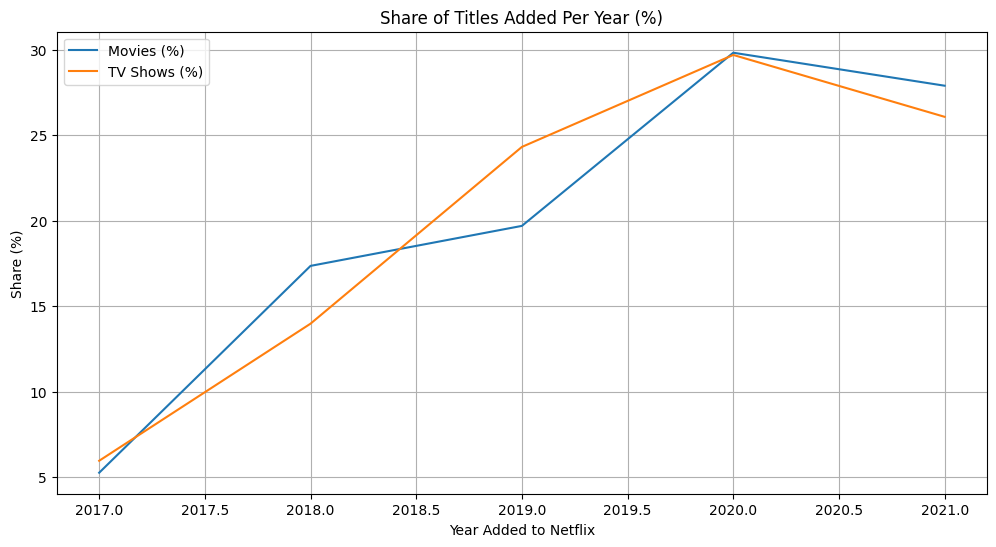

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(share.index, share.get("Movie", 0), label="Movies (%)")
plt.plot(share.index, share.get("TV Show", 0), label="TV Shows (%)")
plt.title("Share of Titles Added Per Year (%)")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Share (%)")
plt.grid()
plt.legend()
plt.show()


In [ ]:
recent = year_type_counts.tail(10)

per = recent.sum()
per = per / per.sum() * 100

print(per.round(2))

type
Movie      64.18
TV Show    35.82
dtype: float64


**Key Insights from the last 10 years**
1. *Nearly 70% of all new titles added in the last decade are movies.*

    This shows Netflix still relies on movies to scale its catalog quickly.
2. *TV Shows are still produced only 30% in comparision to movies. which is growing if we compare from 2010 to 2016 we see a drastic rise in tv show but its not overtaking movies.*

    Even though movies dominate in total share,
    the TV Shows curve rises sharply after 2016 in your graph.

    This means Netflix is increasing investment in series, but not replacing movies.
3. *COVID period strengthened TV Shows’ role
During 2019–2021:*

    TV Show's share becomes more visible , Binge-watching behavior increased

    Even if movies stayed higher in count,
    TV Shows became more critical for retention.

# **6. Understanding what content is available in different countries**

In [ ]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year,month,date,week
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No cast,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25,38
1,s2,TV Show,Blood & Water,No director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,38
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No country,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24,38
3,s4,TV Show,Jailbirds New Orleans,No director,No cast,No country,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,24,38
4,s5,TV Show,Kota Factory,No director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24,38


In [ ]:
country_list = df1["country"].str.split(",").explode()

In [ ]:
country_counts = country_list.value_counts()
print(country_counts.head())

country
United States     1739
No country         662
India              624
United Kingdom     298
 United States     261
Name: count, dtype: int64


In [ ]:
country_counts.info()

<class 'pandas.core.series.Series'>
Index: 160 entries, United States to  Morocco
Series name: count
Non-Null Count  Dtype
--------------  -----
160 non-null    int64
dtypes: int64(1)
memory usage: 2.5+ KB


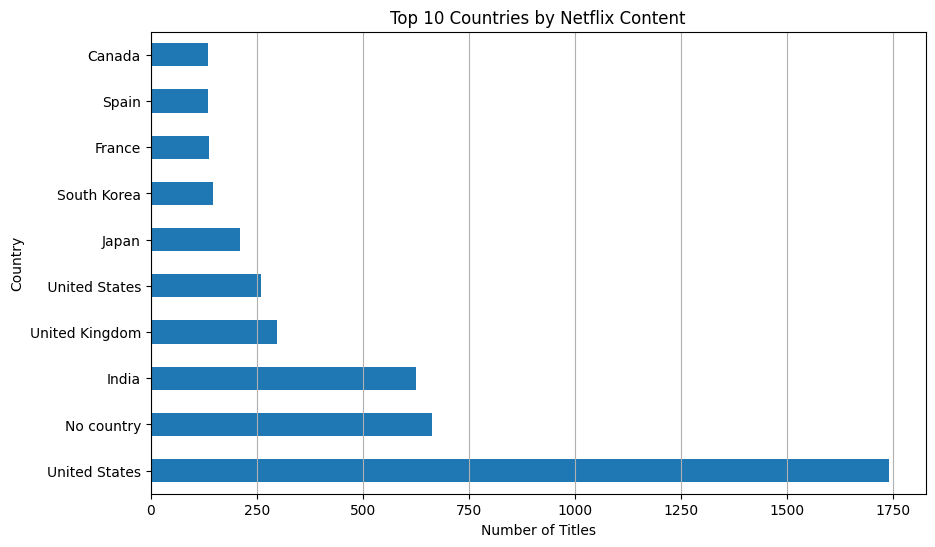

In [ ]:
# plotting top 10 countries by content
top10_countries = country_counts.head(10)
plt.figure(figsize=(10,6))
top10_countries.plot(kind="barh",title="Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.grid(axis="x")
plt.show()


**insights according to this graph**
1. The US is far ahead of every other country in total content,
    until now it produced approx 3500 content.
2. India appears as the second major contributor , it not much as compared to us but it still produced around 1000 content until now
3. Strong presence of Europe & Asia
Countries like:

    United Kingdom,france,japan,canada,south korea
4. “No country” it shows a data quality gap

    A noticeable bar for “No country” means many titles don’t have country metadata

In [ ]:
# preparing data for country and genre
country_genre = df1[["country", "listed_in"]].dropna()

country_genre["country"] = country_genre["country"].str.split(", ")
country_genre["listed_in"] = country_genre["listed_in"].str.split(", ")

country_genre = country_genre.explode("country")
country_genre = country_genre.explode("listed_in")

country_genre["country"] = country_genre["country"].str.strip()
country_genre["listed_in"] = country_genre["listed_in"].str.strip()

In [ ]:
top_country_genre = country_genre[
    country_genre["country"].isin(top10_countries)]

In [ ]:
# count genre for top countries
country_genre_counts = (top_country_genre.groupby(["country", "listed_in"]).size().reset_index(name="count"))

In [ ]:
genre = (country_genre.groupby(["country", "listed_in"]).size().unstack(fill_value=0))

In [ ]:
genre.head()

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Angola,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,1,0,0,0,2,1,1,8,7,1,...,0,1,2,1,0,0,0,0,1,5


In [ ]:
# keeping only top 5 genres overall
top_genres = genre.sum(axis=0).sort_values(ascending=False).head(5).index
print(top_genres)

Index(['International Movies', 'Dramas', 'Comedies', 'International TV Shows',
       'TV Dramas'],
      dtype='object', name='listed_in')


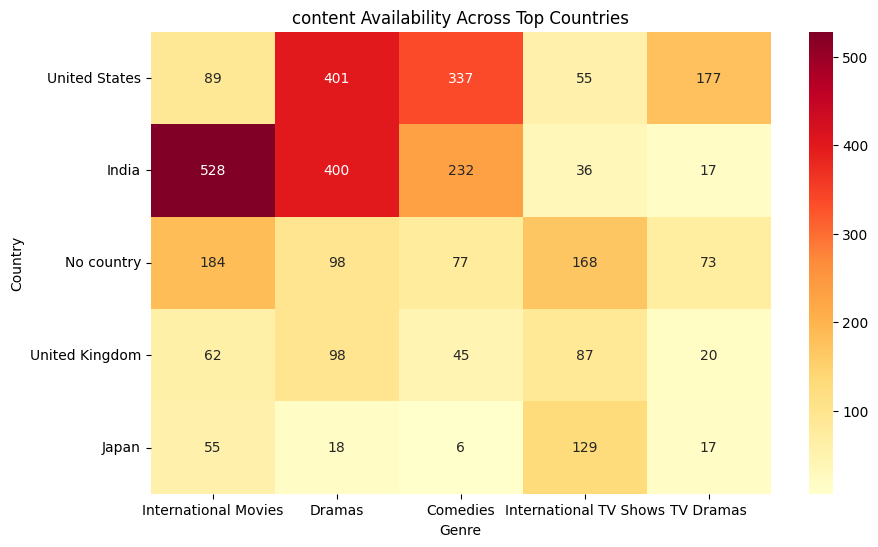

In [ ]:
# plotting the heatmap for top 5 countries by top 5 content type.
top_countries = (genre.sum(axis=1).sort_values(ascending=False).head(5).index)
heatmap_data = genre.loc[top_countries, top_genres]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,annot=True,fmt=".0f",cmap="YlOrRd")

plt.title("content Availability Across Top Countries")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.show()


**Insights on top 5 content types on top countries**
1. **United States** has the most balanced genre mix
- Strong presence across Dramas (401), Comedies (337), and TV Dramas (177).
- No single genre dominates completely
2. **India** is highly movie and drama centric
- Very high International Movies (528) and Dramas (400).
- Very low International TV Shows (36) and TV Dramas (17).
3. **Japan** is clearly TV-show focused
- High International TV Shows (129) compared to movies and comedies.
- Very low Comedies (6).
4. **“No country”** indicates a data quality gap
- Significant counts across genres for No country.
5. **United Kingdom** prefers TV-centric content.
- Moderate Dramas (98) and International TV Shows (87).

#**Final Rcommendation**
1. **Movies vs TV Shows**
- Continue using movies to scale the catalog quickly
- Increase investment in TV Shows to improve:
   - binge-watching
  - subscriber retention
   - long-term engagement
2. **Plan major TV Show launches during:**
- high engagement periods
- holiday seasons ( due to our findings on COVID years (2019–2021)).
3. **Improve metadata quality (cast & director tagging)**
4. **Continue working with diverse creators instead of relying on few big names.**
5. **Use repeat collaborations selectively for popular regional creators.**
6. **Country-wise Content Distribution:**
    - Expand TV Shows in India to improve retention.
    - Invest more in series-based content for Japan & Korea.
    - Fix missing country tags for accurate regional strategy.
7. **Genre Analysis Across Top Countries**
- Expand:
    - Indian TV dramas
    - Japanese comedy & experimental genres

# **FINAL CONCLUSION**

Through this analysis, I found that Netflix uses movies to rapidly expand its catalog while TV shows play a key role in long-term user engagement. Content strategy varies significantly by country and genre, showing a strong localized approach. The analysis also highlighted metadata gaps, which present an opportunity to improve data-driven decision-making.